<a href="https://colab.research.google.com/github/siva651/Movie-RecommendationSystem/blob/main/Movie_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ---- STEP 1: Setup ----
!pip install nltk --quiet

import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
print("Libraries loaded")

Libraries loaded


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
# ---- STEP 2: Load data ----
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q -o ml-100k.zip

# movie titles + genre flags
cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL',
        'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
        'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
        'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
genre_cols = cols[6:]

movies = pd.read_csv('ml-100k/u.item', sep='|', names=cols, encoding='latin-1')
movies = movies[['movie_id', 'title'] + genre_cols]

# who rated what
ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                       names=['user_id', 'movie_id', 'rating', 'timestamp'])

print(f"Movies: {len(movies)} | Ratings: {len(ratings)}")

Movies: 1682 | Ratings: 100000



Movies sample:


,movie_id,title,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0



Ratings sample:


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



Users: 943
Rating range: 1-5, avg 3.53


/tmp/ipykernel_843/2950570954.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


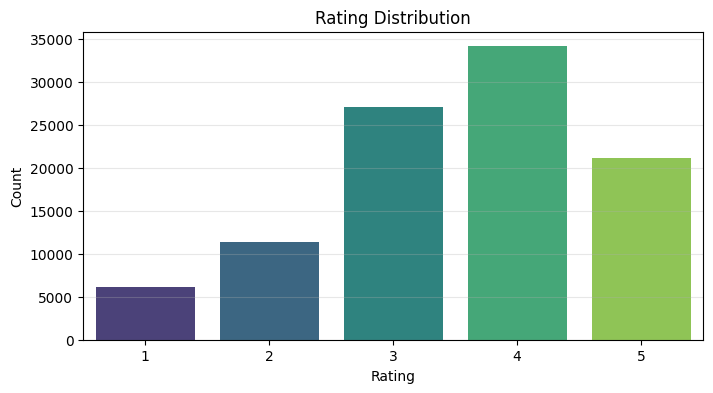

/tmp/ipykernel_843/2950570954.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='coolwarm')


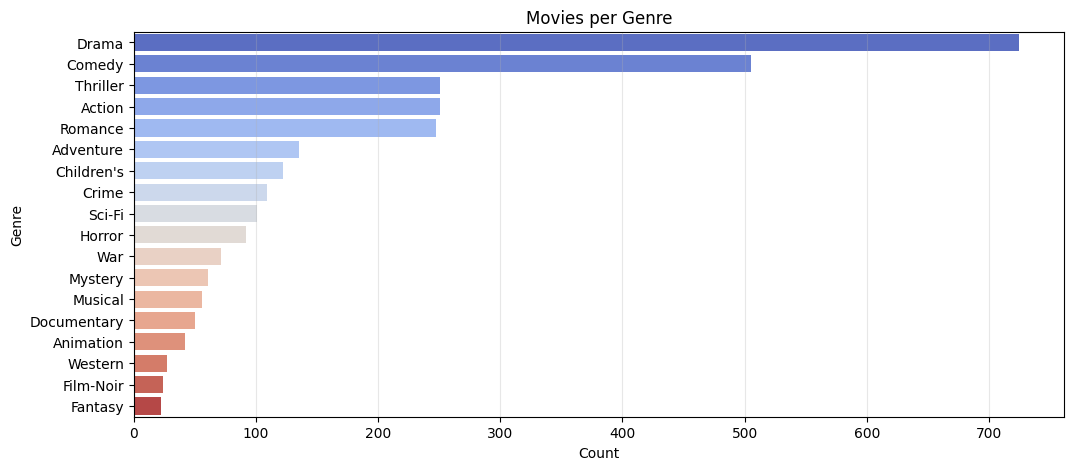

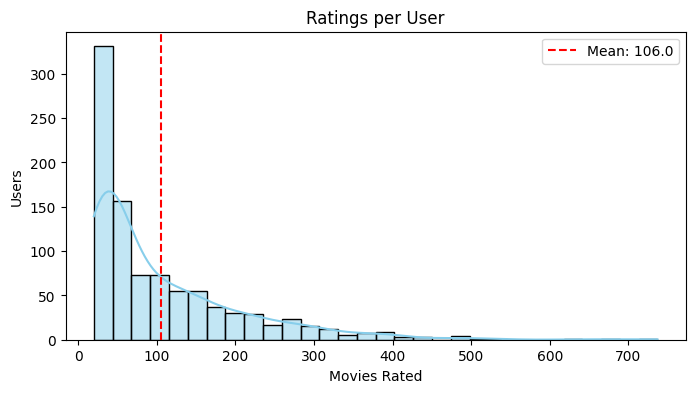

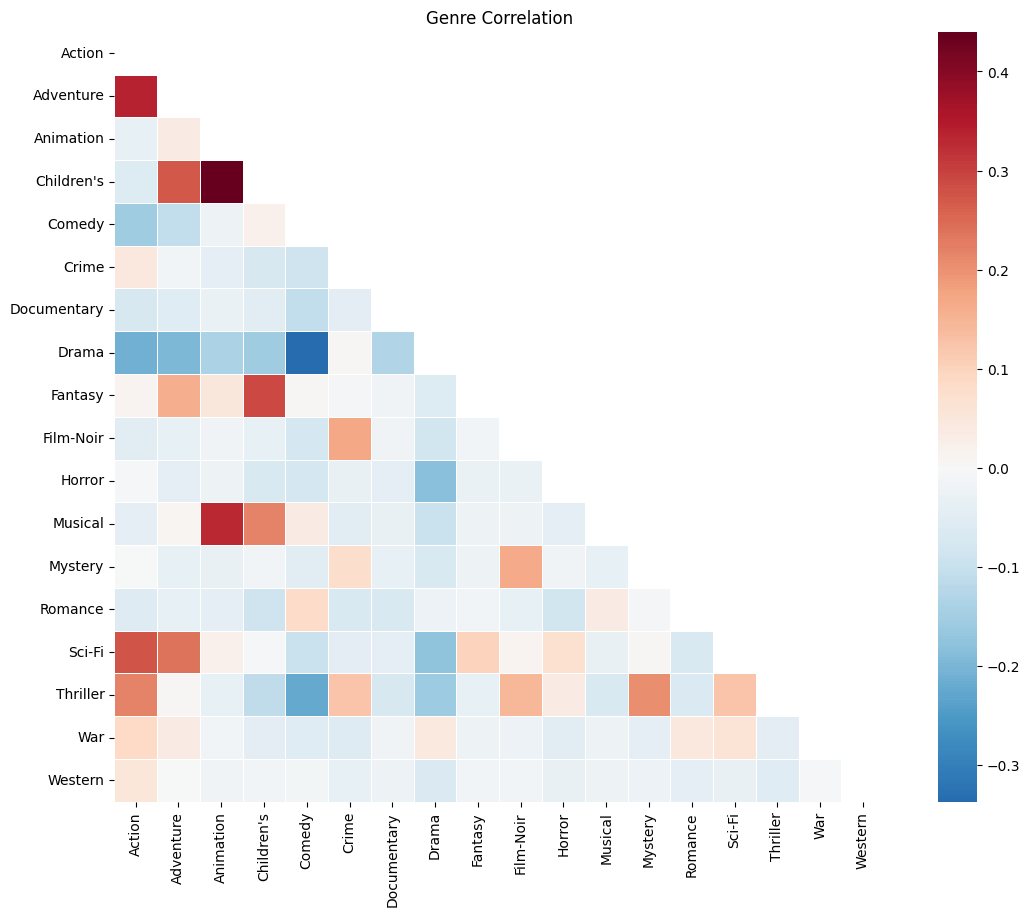

In [3]:
# ---- STEP 3: Explore the data ----
print("\nMovies sample:")
display(movies.head())
print("\nRatings sample:")
display(ratings.head())

print(f"\nUsers: {ratings['user_id'].nunique()}")
print(f"Rating range: {ratings['rating'].min()}-{ratings['rating'].max()}, "
      f"avg {ratings['rating'].mean():.2f}")

# how ratings are distributed
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating'); plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# which genres have the most movies
genre_counts = movies[genre_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='coolwarm')
plt.title('Movies per Genre')
plt.xlabel('Count'); plt.ylabel('Genre')
plt.grid(axis='x', alpha=0.3)
plt.show()

# how active users are
activity = ratings.groupby('user_id').size()
plt.figure(figsize=(8, 4))
sns.histplot(activity, bins=30, kde=True, color='skyblue')
plt.axvline(activity.mean(), color='red', linestyle='--', label=f'Mean: {activity.mean():.1f}')
plt.title('Ratings per User')
plt.xlabel('Movies Rated'); plt.ylabel('Users')
plt.legend()
plt.show()

# which genres tend to appear together
plt.figure(figsize=(14, 10))
corr = movies[genre_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, linewidths=0.5, square=True)
plt.title('Genre Correlation')
plt.show()

In [4]:
# ---- STEP 4: Turn each movie into text (title + genres) ----
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    """lowercase, drop stopwords, stem"""
    text = text.split('(')[0].strip()  # drop year e.g. (1995)
    words = [w for w in text.lower().split() if w not in stop_words]
    return ' '.join(stemmer.stem(w) for w in words)

def movie_to_text(row):
    title_part = clean_text(row['title'])
    genre_part = ' '.join(g for g in genre_cols if row[g] == 1)
    return f"{title_part} {clean_text(genre_part)}"

movies['combined_text'] = movies.apply(movie_to_text, axis=1)
print(movies[['title', 'combined_text']].head(3))

               title                      combined_text
0   Toy Story (1995)    toy stori anim children' comedi
1   GoldenEye (1995)  goldeney action adventur thriller
2  Four Rooms (1995)                 four room thriller


In [5]:
# ---- STEP 5: Vectorize with TF-IDF ----
tfidf = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf.fit_transform(movies['combined_text'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")


TF-IDF matrix shape: (1682, 500)


In [6]:
# ---- STEP 6: Build a "taste profile" per user ----
def get_user_profile(user_id, min_rating=4):
    """average TF-IDF vector of movies the user rated highly"""
    liked_ids = ratings[(ratings['user_id'] == user_id) &
                         (ratings['rating'] >= min_rating)]['movie_id']
    idx = movies[movies['movie_id'].isin(liked_ids)].index
    if len(idx) == 0:
        return np.zeros(tfidf_matrix.shape[1])
    return np.asarray(tfidf_matrix[idx].mean(axis=0)).flatten()


In [7]:
# ---- STEP 7: Pick users to test on ----
test_users = []
for user_id in ratings['user_id'].unique():
    liked = ratings[(ratings['user_id'] == user_id) & (ratings['rating'] >= 4)]['movie_id'].tolist()
    if len(liked) < 5:
        continue
    train_liked, test_liked = train_test_split(liked, test_size=0.2, random_state=42)
    test_users.append({'user_id': user_id, 'test_movies': test_liked})

print(f"Evaluating on {len(test_users)} users")


Evaluating on 938 users


In [8]:
# ---- STEP 8: Evaluate recommendations ----
SIMILARITY_THRESHOLD = 0.010  # tune this to trade precision vs recall

y_true, y_pred = [], []
precision_at_10_list = []

for user in test_users:
    user_id = user['user_id']
    profile = get_user_profile(user_id)

    # score every movie the user has rated (not just the test split)
    history = ratings[ratings['user_id'] == user_id]
    scores = []
    for movie_id, actual_rating in zip(history['movie_id'], history['rating']):
        idx = movies[movies['movie_id'] == movie_id].index
        if len(idx) == 0:
            continue
        vec = tfidf_matrix[idx[0]].toarray().flatten()
        sim = cosine_similarity([profile], [vec])[0][0]
        scores.append((sim, actual_rating))

    scores.sort(key=lambda x: x[0], reverse=True)

    # Precision@10: of our top 10 picks, how many did the user actually like?
    top_10 = scores[:10]
    precision_at_10_list.append(sum(r >= 4 for _, r in top_10) / 10)

    # feed confusion matrix / precision / recall / f1
    for sim, actual_rating in scores:
        y_true.append(1 if actual_rating >= 4 else 0)
        y_pred.append(1 if sim >= SIMILARITY_THRESHOLD else 0)

avg_precision_at_10 = np.mean(precision_at_10_list)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\nPrecision@10: {avg_precision_at_10:.2%}")
print(f"Precision: {precision:.2%} | Recall: {recall:.2%} | F1: {f1:.2%}")


Precision@10: 72.63%
Precision: 55.65% | Recall: 99.99% | F1: 71.51%


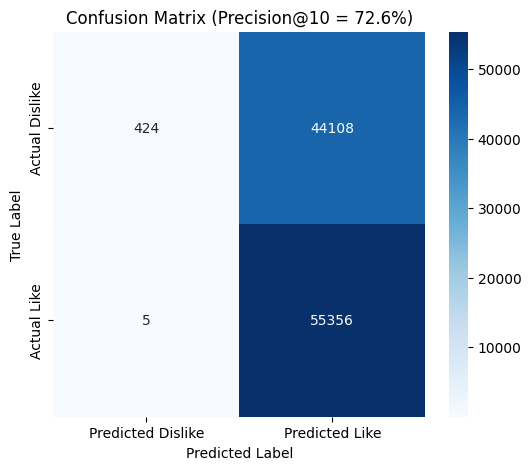

Saved confusion_matrix.png


In [9]:
# ---- STEP 9: Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dislike', 'Predicted Like'],
            yticklabels=['Actual Dislike', 'Actual Like'])
plt.title(f'Confusion Matrix (Precision@10 = {avg_precision_at_10:.1%})')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
plt.show()

print("Saved confusion_matrix.png")
